# Running Forecasts — Hosted CorrDiff Endpoint

Steps 1–5 from [HostedInference.md](HostedInference.md), ready to run — no copy-pasting
required. Run the cells in order (Cell → Run All, or step through one at a time).

> **This endpoint is shared and has no authentication.** Please be considerate of usage
> (keep `samples`/`steps` reasonable) since it runs on a shared lab GPU that other people
> are using too. It's only reachable while the host has their NIM deployment running — if
> requests fail to connect, it may simply be offline.

## Step 1 — Check the endpoint is up

In [1]:
import requests

BASE_URL = "https://corrdiff-laurahu.nrp-nautilus.io"

r = requests.get(f"{BASE_URL}/v1/health/ready")
print(r.status_code, r.text)

200 {"status":"ready"}


## Step 2 — Build an input tensor

CorrDiff expects a specific stack of GEFS variables cropped to a CONUS bounding box, plus a
lead-time field. This runs entirely on CPU.

In [2]:
import os
import posixpath
from datetime import datetime, timedelta
import numpy as np
import torch
from earth2studio.data import GEFS_FX, GEFS_FX_721x1440

# Windows-only fix: earth2studio's GEFS source builds S3 object keys with os.path.join,
# which uses backslashes on Windows -> invalid keys -> 404 FileNotFoundError. This makes
# it use forward slashes instead, without touching os.path anywhere else in the process.
# No-op on Mac/Linux, where os.path.join already produces forward slashes.
if os.name == "nt":
    import earth2studio.data.gefs as _gefs_module

    class _PosixOSProxy:
        path = posixpath
        def __getattr__(self, name):
            return getattr(os, name)

    _gefs_module.os = _PosixOSProxy()

GEFS_SELECT_VARIABLES = ["u10m", "v10m", "t2m", "r2m", "sp", "msl", "tcwv"]
GEFS_VARIABLES = [
    "u1000", "u925", "u850", "u700", "u500", "u250",
    "v1000", "v925", "v850", "v700", "v500", "v250",
    "z1000", "z925", "z850", "z700", "z500", "z200",
    "t1000", "t925", "t850", "t700", "t500", "t100",
    "r1000", "r925", "r850", "r700", "r500", "r100",
]

ds_gefs = GEFS_FX(cache=True)
ds_gefs_select = GEFS_FX_721x1440(cache=True, member="gec00")

def fetch_input_gefs(time: datetime, lead_time: timedelta, content_dtype: str = "float32"):
    dtype = np.dtype(getattr(np, content_dtype))
    g = np.array(9.80665, dtype=dtype)

    select_data = ds_gefs_select(time, lead_time, GEFS_SELECT_VARIABLES).values
    select_data = select_data[:, 0, :, 148:277, 900:1201].astype(dtype)

    pressure_data = ds_gefs(time, lead_time, GEFS_VARIABLES)
    pressure_data = torch.nn.functional.interpolate(
        torch.as_tensor(pressure_data.values),
        (len(GEFS_VARIABLES), 721, 1440),
        mode="nearest",
    ).numpy()
    pressure_data = pressure_data[:, 0, :, 148:277, 900:1201].astype(dtype)

    z_vars = {"z1000", "z925", "z850", "z700", "z500", "z200"}
    z_indices = [i for i, v in enumerate(GEFS_VARIABLES) if v in z_vars]
    pressure_data[:, z_indices, :, :] /= g

    lead_hour = (int(lead_time.total_seconds() // (3 * 60 * 60))
                 * np.ones((1, 1, 129, 301), dtype=dtype))

    return np.concatenate([select_data, pressure_data, lead_hour], axis=1)[None]

# Example: Tennessee Valley flood, forecast initialized 2025-04-04 00Z, 24-hour lead time
time = datetime(2025, 4, 4)
lead_time = timedelta(hours=24)  # must be a multiple of 3 hours, up to 24
input_array = fetch_input_gefs(time, lead_time)
np.save("corrdiff_inputs.npy", input_array)


Fetching GEFS data:   0%|          | 0/7 [00:00<?, ?it/s]


Fetching GEFS data:   0%|          | 0/7 [00:00<?, ?it/s]


Fetching GEFS data:   0%|          | 0/7 [00:00<?, ?it/s]


Fetching GEFS data:   0%|          | 0/7 [00:00<?, ?it/s]


Fetching GEFS data:   0%|          | 0/7 [00:00<?, ?it/s]

...


Fetching GEFS data:   0%|          | 0/30 [00:00<?, ?it/s]


Fetching GEFS data:   0%|          | 0/30 [00:00<?, ?it/s]

2026-08-07 12:25:19.652 | DEBUG    | earth2studio.data.gefs:fetch_array:401 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20250404/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 9637068-270785
2026-08-07 12:25:19.653 | DEBUG    | earth2studio.data.gefs:fetch_array:401 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20250404/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 9138152-235164
2026-08-07 12:25:19.657 | DEBUG    | earth2studio.data.gefs:fetch_array:401 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20250404/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 6126853-246007
2026-08-07 12:25:19.661 | DEBUG    | earth2studio.data.gefs:fetch_array:401 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20250404/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 10531663-266541
2026-08-07 12:25:19.664 | DEBUG    | earth2studio.data.gefs:fetch_array:401 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20250404/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f024 5798376-161286
2026-08-07 12:25:19.667 | DEBUG    | ea


Fetching GEFS data:   3%|▎         | 1/30 [00:00<00:03,  8.60it/s]


Fetching GEFS data: 100%|██████████| 30/30 [00:00<00:00, 256.64it/s]

## Step 3 — Send the inference request

In [3]:
r = requests.post(
    f"{BASE_URL}/v1/infer",
    headers={"accept": "application/x-tar"},
    data={
        "samples": 2,   # number of ensemble members
        "steps": 8,    # diffusion steps
        "seed": 0,
    },
    files={"input_array": ("input_array", open("corrdiff_inputs.npy", "rb"))},
    timeout=3000,
)
if r.status_code != 200:
    raise Exception(r.content)

with open("output.tar", "wb") as f:
    f.write(r.content)

## Step 4 — Read the output

Each ensemble member comes back as a `.npy` file inside the tar archive.

In [4]:
import io, tarfile
import numpy as np

samples = []
with tarfile.open("output.tar") as tar:
    for member in tar.getmembers():
        buf = io.BytesIO(tar.extractfile(member).read())
        buf.seek(0)
        samples.append(np.load(buf))

print(len(samples), samples[0].shape)

2 (1, 1, 8, 1056, 1792)


Output channel order is `["u10m", "v10m", "t2m", "tp", "csnow", "cicep", "cfrzr", "crain"]`.
For lat/lon coordinates to map the CONUS output grid, this notebook expects
`corrdiff_output_lat.npy` and `corrdiff_output_lon.npy` (from this repo) in the same folder.

## Step 5 — Visualize a variable

`matplotlib` and `cartopy` are included via `uv sync` / `environment.yml`. Here's the
ensemble-mean 10m wind speed plotted on a Lambert Conformal projection over CONUS:

/Users/laurahu/Documents/ResearchClimate/CorrDiffSCIL/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


/Users/laurahu/Documents/ResearchClimate/CorrDiffSCIL/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


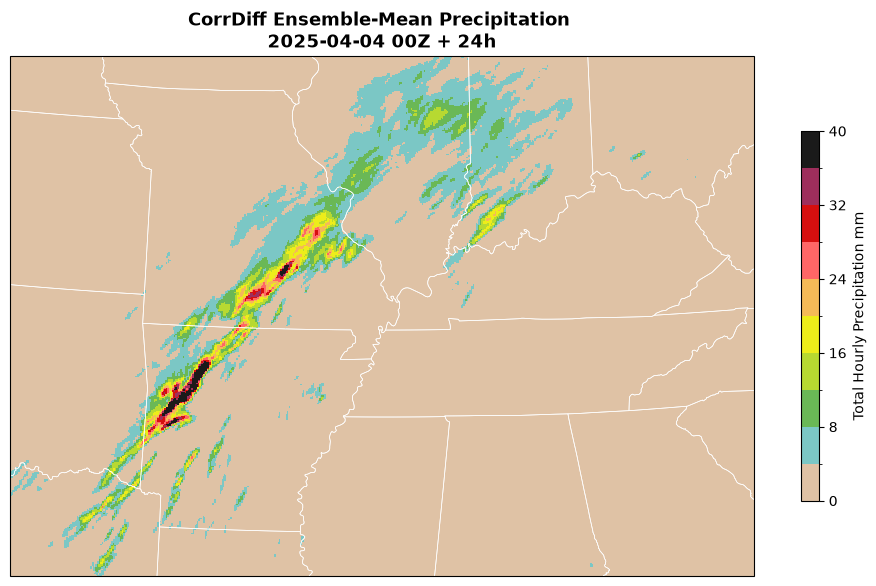

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lats = np.load("corrdiff_output_lat.npy")
lons = np.load("corrdiff_output_lon.npy") - 360

precp = np.mean([s[0, 0, 3] for s in samples], axis=0)

# Zoom to the Tennessee Valley region
LAT_MIN, LAT_MAX = 32.0, 41.0
LON_MIN, LON_MAX = -97.0, -82.0

# GPCP-style precipitation color scale
gpcp_colors = [
    '#dfc2a5', '#7ec9d0', '#5eb35e', '#99cc33', '#f2f22e',
    '#e6e600', '#ff9999', '#ff4d4d', '#cc0000', '#993366', '#1a1a1a'
]
continuous_cmap = mcolors.LinearSegmentedColormap.from_list("gpcp_cont", gpcp_colors)
hour_levels = np.linspace(0, 40, 11)  # single lead time, not an accumulated total
custom_cmap = mcolors.ListedColormap(continuous_cmap(np.linspace(0, 1, len(hour_levels) - 1)))
norm = mcolors.BoundaryNorm(hour_levels, ncolors=custom_cmap.N)

projection = ccrs.LambertConformal(
    central_longitude=(LON_MIN + LON_MAX) / 2,
    central_latitude=(LAT_MIN + LAT_MAX) / 2,
    standard_parallels=(33, 45),
)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
c = ax.pcolormesh(lons, lats, precp, transform=ccrs.PlateCarree(), cmap=custom_cmap, norm=norm)
ax.coastlines(linewidth=1)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="white")

ax.set_title(
    f"CorrDiff Ensemble-Mean Precipitation \n{time:%Y-%m-%d %HZ} + {int(lead_time.total_seconds() // 3600)}h",
    fontsize=13, fontweight = 'bold'
)
fig.colorbar(c, ax=ax, shrink=0.6, ticks=hour_levels[::2], label="Total Hourly Precipitation mm")
fig.savefig("precp.png", dpi=150)
plt.show()  # displays inline if you're in a notebook; no-op otherwise

> **Note:** the first time `cfeature.STATES`/`.coastlines()` run, cartopy downloads Natural
> Earth map data from the internet and caches it locally — expect a short delay on first use only.